In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
pip install torch torchvision matplotlib numpy pillow

In [11]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [12]:
dataset_path = Path('/content/drive/MyDrive/Colab Notebooks/final_dataset')

In [13]:
# Check whether the dataset folder exists
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {dataset_path}"
    )

print("Dataset found!")
print("Location:", dataset_path)

# Display the first two folder levels
for item in sorted(dataset_path.iterdir()):
    print(f"\n📁 {item.name}")

    if item.is_dir():
        for subitem in sorted(item.iterdir()):
            print(f"    └── {subitem.name}")

Dataset found!
Location: /content/drive/MyDrive/Colab Notebooks/final_dataset

📁 corrupted_images
    └── test
    └── train
    └── val

📁 test
    └── accepted
    └── rejected

📁 train
    └── accepted
    └── rejected

📁 val
    └── accepted
    └── rejected


In [14]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [23]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(dataset_path, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


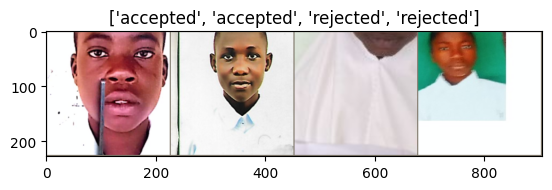

In [24]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [29]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=50):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [30]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [31]:
model_ft = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.DEFAULT
)
# Get the number of inputs to the final classification layer
num_ftrs = model_ft.classifier[-1].in_features

# Replace the final layer with a binary classifier
model_ft.classifier[-1] = nn.Linear(num_ftrs, 2)

print(model_ft.classifier)
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=50)

Epoch 0/49
----------
train Loss: 0.2944 Acc: 0.8889
val Loss: 0.2323 Acc: 0.9146

Epoch 1/49
----------
train Loss: 0.2457 Acc: 0.9118
val Loss: 0.2176 Acc: 0.9225

Epoch 2/49
----------
train Loss: 0.2300 Acc: 0.9158
val Loss: 0.2127 Acc: 0.9172

Epoch 3/49
----------
train Loss: 0.2254 Acc: 0.9165
val Loss: 0.2100 Acc: 0.9225

Epoch 4/49
----------
train Loss: 0.2187 Acc: 0.9198
val Loss: 0.2071 Acc: 0.9225

Epoch 5/49
----------
train Loss: 0.2095 Acc: 0.9233
val Loss: 0.2018 Acc: 0.9185

Epoch 6/49
----------
train Loss: 0.2091 Acc: 0.9221
val Loss: 0.2042 Acc: 0.9172

Epoch 7/49
----------
train Loss: 0.2011 Acc: 0.9254
val Loss: 0.2012 Acc: 0.9219

Epoch 8/49
----------
train Loss: 0.1968 Acc: 0.9255
val Loss: 0.2000 Acc: 0.9232

Epoch 9/49
----------
train Loss: 0.1966 Acc: 0.9263
val Loss: 0.1994 Acc: 0.9219

Epoch 10/49
----------
train Loss: 0.1934 Acc: 0.9259
val Loss: 0.2001 Acc: 0.9219

Epoch 11/49
----------
train Loss: 0.1943 Acc: 0.9264
val Loss: 0.2009 Acc: 0.9192

Ep

In [ ]:
visualize_model(model_ft)

plt.ioff()
plt.show()

In [ ]:
import torch

# Save the trained model weights
torch.save(model_ft, "fine_tuned_model.pth")

print("Model saved successfully!")

In [ ]:
import torch

# Save the trained model weights
torch.save(model_ft.state_dict(), "fine_tuned_model_weights.pth")

print("Model saved successfully!")

In [ ]:
from google.colab import files

files.download("fine_tuned_model_weights.pth")